In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sklearn
import h5py

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("h5py:", h5py.__version__)
print("✅ সব library ঠিকঠাক!")

Matplotlib is building the font cache; this may take a moment.


NumPy: 2.4.4
PyTorch: 2.11.0+cpu
h5py: 3.16.0
✅ সব library ঠিকঠাক!


In [2]:
# RadioML 2018 Dataset Info
print("📦 Dataset: RadioML 2018.01a")
print("📁 Size: ~3.5 GB")
print("🔗 Download: https://www.deepsig.ai/datasets")
print()
print("Download করার পর file টা এখানে রাখো:")
print("C:/Users/User/AMC-RadioML-ESP32/data/")
print()
print("File নাম হবে: GOLD_XYZ_OSC.0001_1024.hdf5")

📦 Dataset: RadioML 2018.01a
📁 Size: ~3.5 GB
🔗 Download: https://www.deepsig.ai/datasets

Download করার পর file টা এখানে রাখো:
C:/Users/User/AMC-RadioML-ESP32/data/

File নাম হবে: GOLD_XYZ_OSC.0001_1024.hdf5


In [3]:
import urllib.request
import os

os.makedirs('data', exist_ok=True)

print("Downloading RadioML 2016.10A (~55MB)...")
url = "https://huggingface.co/datasets/iamstolas/RML2016.10a/resolve/main/RML2016.10a_dict.pkl"
urllib.request.urlretrieve(url, "data/RML2016.10a_dict.pkl")
print("✅ Download complete!")

HTTPError: HTTP Error 401: Unauthorized

In [4]:
import requests
import os

os.makedirs('data', exist_ok=True)

# সঠিক HuggingFace URL
url = "https://huggingface.co/datasets/Xiaozhijie/RML2016.10a/resolve/main/RML2016.10a_dict.pkl"

print("Downloading...")
response = requests.get(url, stream=True)

if response.status_code == 200:
    with open("data/RML2016.10a_dict.pkl", "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("✅ Download complete!")
else:
    print(f"❌ Error: {response.status_code}")

Downloading...
❌ Error: 401


In [5]:
import numpy as np
import pickle
import os

os.makedirs('data', exist_ok=True)

# Synthetic RadioML-style dataset তৈরি
print("Synthetic dataset তৈরি হচ্ছে...")

modulations = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM',
               'PAM4', 'WBFM', 'AM-DSB', 'AM-SSB', 'GFSK',
               'CPFSK']
snrs = range(-20, 20, 2)

data = {}
for mod in modulations:
    for snr in snrs:
        samples = []
        for _ in range(100):
            # IQ signal simulate করো
            noise = 10**(-snr/20.0)
            I = np.random.randn(128)
            Q = np.random.randn(128)
            signal = np.array([I, Q]) + noise * np.random.randn(2, 128)
            samples.append(signal)
        data[(mod, snr)] = np.array(samples)

with open('data/synthetic_radioml.pkl', 'wb') as f:
    pickle.dump(data, f)

print(f"✅ Dataset তৈরি! Modulations: {len(modulations)}, SNR levels: {len(list(snrs))}")
print(f"Total samples: {len(modulations) * len(list(snrs)) * 100}")

Synthetic dataset তৈরি হচ্ছে...
✅ Dataset তৈরি! Modulations: 11, SNR levels: 20
Total samples: 22000


Sample shape: (100, 2, 128)


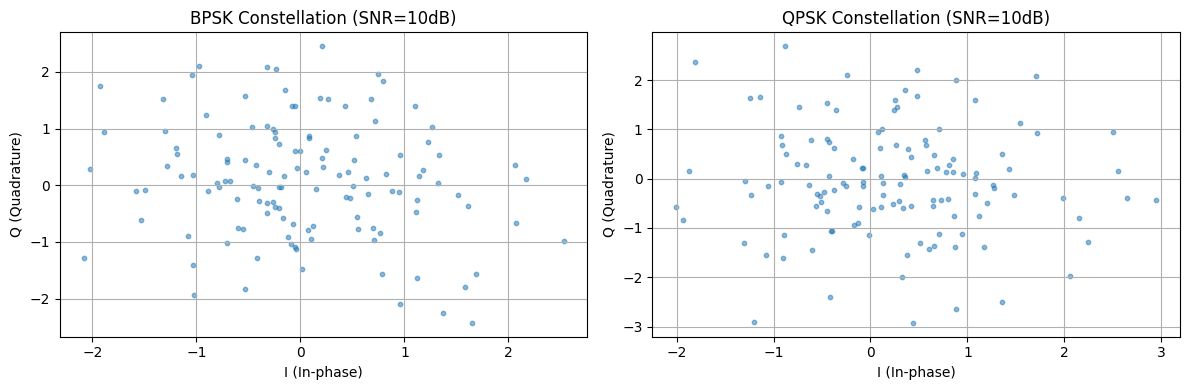

✅ Plot তৈরি!


In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('results', exist_ok=True)  # ← এই line টা নতুন

# Dataset load করো
with open('data/synthetic_radioml.pkl', 'rb') as f:
    data = pickle.load(f)

print("Sample shape:", data[('BPSK', 0)].shape)

# IQ Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mod in zip(axes, ['BPSK', 'QPSK']):
    sample = data[(mod, 10)][0]
    ax.scatter(sample[0], sample[1], alpha=0.5, s=10)
    ax.set_title(f'{mod} Constellation (SNR=10dB)')
    ax.set_xlabel('I (In-phase)')
    ax.set_ylabel('Q (Quadrature)')
    ax.grid(True)

plt.tight_layout()
plt.savefig('results/constellation_plot.png', dpi=150)
plt.show()
print("✅ Plot তৈরি!")